# Mostafa_Ensemble — Ensemble Learning with XAI

This notebook combines VGG19, ResNet50, and CNN+LSTM predictions using soft voting ensemble.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


In [2]:
import kagglehub
import pandas as pd
import os

from pathlib import Path
from sklearn.model_selection import train_test_split

SEED = 42

dataset_path = kagglehub.dataset_download(
    "fernando2rad/x-ray-lung-diseases-images-9-classes"
)

rows = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        ):

            filepath = Path(root) / file
            label = Path(root).name

            rows.append([str(filepath), label])

df = pd.DataFrame(rows, columns=["filepath", "label"])

class_counts = df["label"].value_counts()

valid_classes = class_counts[class_counts > 50].index

df = df[df["label"].isin(valid_classes)].reset_index(drop=True)

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=SEED
)



100%|██████████| 182M/182M [00:01<00:00, 130MB/s]

Extracting files...


In [3]:
class_names = sorted(df["label"].unique())

label_to_index = {
    label: i
    for i, label in enumerate(class_names)
}

y_true = test_df["label"].map(label_to_index).values



## Load Saved Predictions

In [4]:
pred_vgg19 = np.load("vgg19_predictions.npy")
pred_resnet50 = np.load("resnet50_predictions.npy")
pred_cnn_lstm = np.load("cnn_lstm_predictions.npy")



## Check Shapes

In [5]:
print("VGG19:", pred_vgg19.shape)
print("ResNet50:", pred_resnet50.shape)
print("CNN+LSTM:", pred_cnn_lstm.shape)
print("True labels:", y_true.shape)


VGG19: (1012, 9)
ResNet50: (1012, 9)
CNN+LSTM: (1012, 9)
True labels: (1012,)


## Soft Voting Ensemble

In [6]:
ensemble_pred = (
    pred_vgg19 +
    pred_resnet50 +
    pred_cnn_lstm
) / 3

y_pred_ensemble = np.argmax(ensemble_pred, axis=1)


## Ensemble Evaluation

In [7]:
ensemble_acc = accuracy_score(y_true, y_pred_ensemble)
ensemble_f1 = f1_score(y_true, y_pred_ensemble, average="macro")

print("Ensemble Accuracy:", ensemble_acc)
print("Ensemble Macro F1:", ensemble_f1)

print(classification_report(
    y_true,
    y_pred_ensemble,
    target_names=class_names
))


Ensemble Accuracy: 0.9940711462450593
Ensemble Macro F1: 0.9956561328167154
                                                                                           precision    recall  f1-score   support

                                                                       00 Anatomia Normal       0.99      1.00      0.99       201
                                        01 Processos Inflamatórios Pulmonares (Pneumonia)       0.99      0.97      0.98       159
     02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)       1.00      1.00      1.00       102
                      03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)       1.00      1.00      1.00        95
   04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)       1.00      0.99      0.99        97
      05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)       1.00      1.00      1.00        89
      

## Confusion Matrix

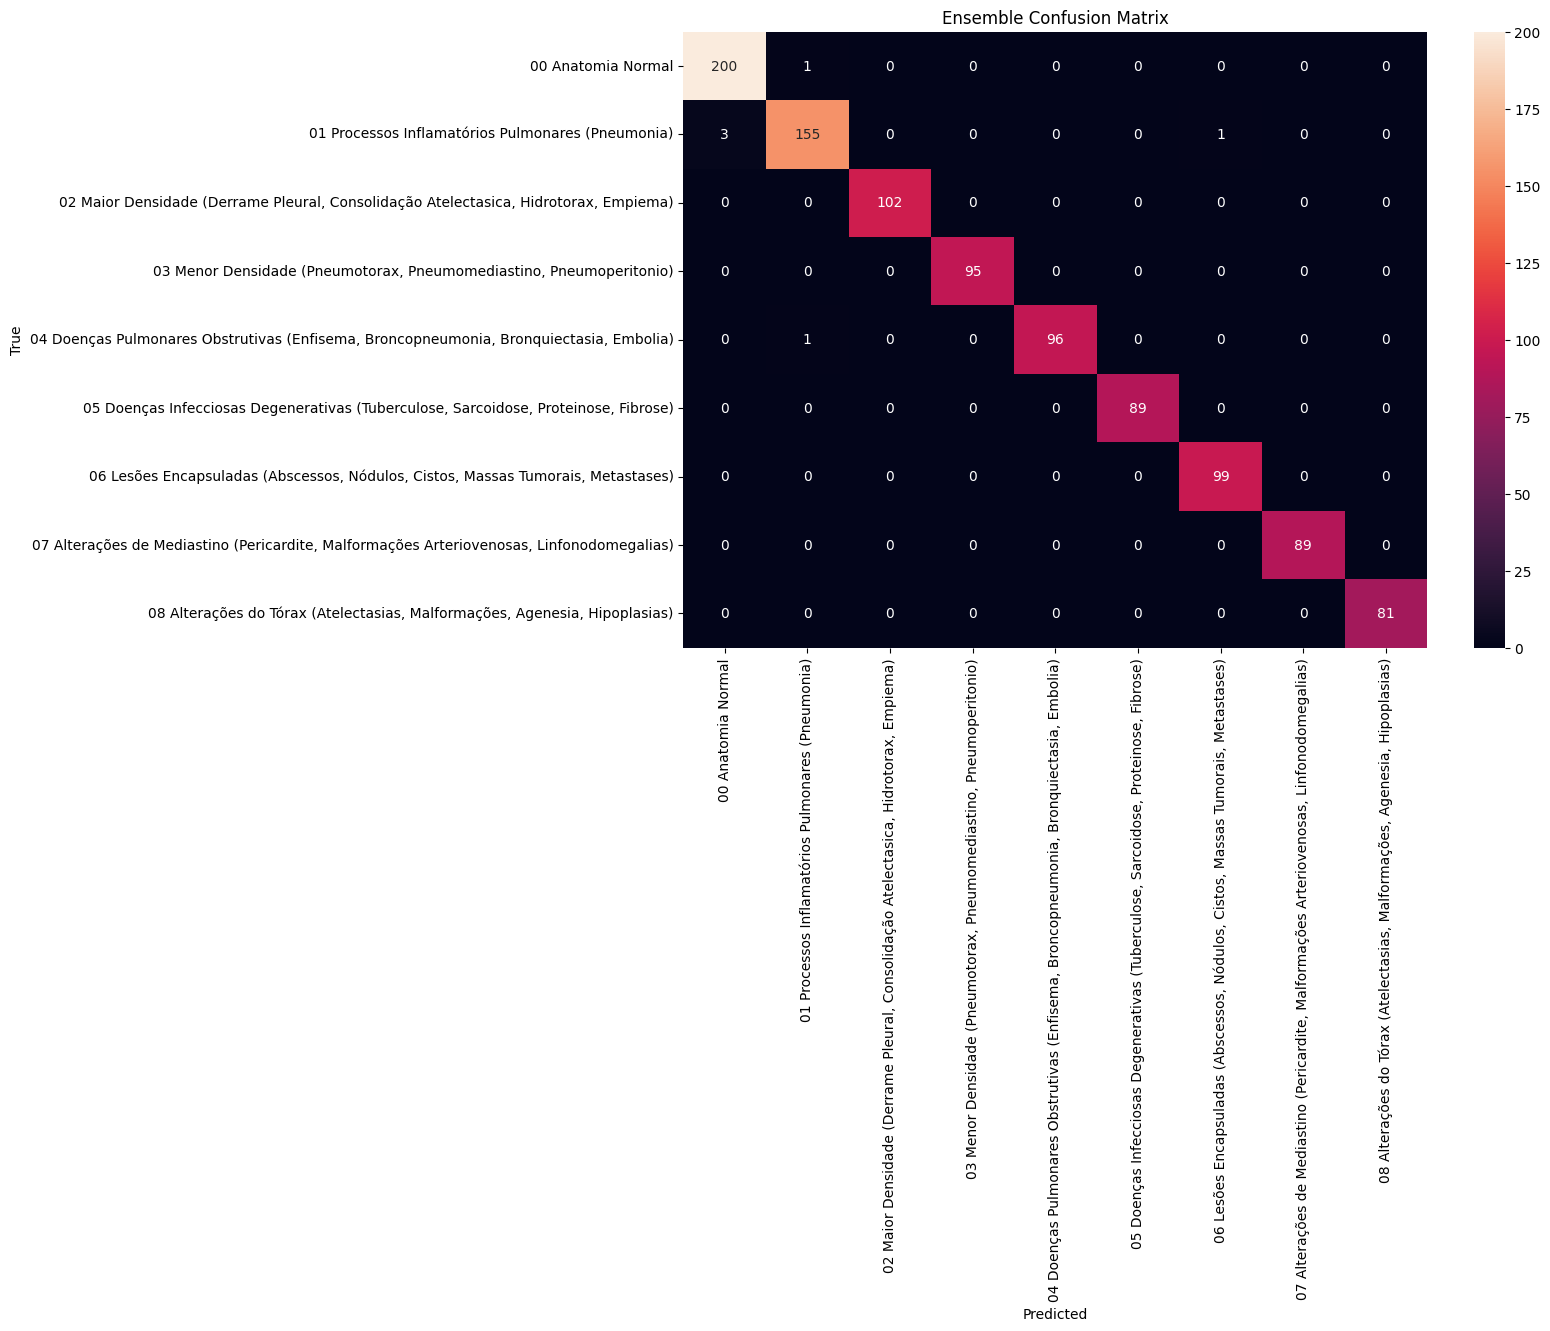

In [8]:
cm = confusion_matrix(y_true, y_pred_ensemble)

plt.figure(figsize=(12, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90)

plt.show()


## Model Comparison

In [9]:
comparison = pd.DataFrame({
    "Model": ["VGG19", "ResNet50", "CNN+LSTM", "Ensemble"],
    "Accuracy": [
        accuracy_score(y_true, np.argmax(pred_vgg19, axis=1)),
        accuracy_score(y_true, np.argmax(pred_resnet50, axis=1)),
        accuracy_score(y_true, np.argmax(pred_cnn_lstm, axis=1)),
        ensemble_acc
    ],
    "Macro F1": [
        f1_score(y_true, np.argmax(pred_vgg19, axis=1), average="macro"),
        f1_score(y_true, np.argmax(pred_resnet50, axis=1), average="macro"),
        f1_score(y_true, np.argmax(pred_cnn_lstm, axis=1), average="macro"),
        ensemble_f1
    ]
})

comparison


,Model,Accuracy,Macro F1
0,VGG19,0.986166,0.988464
1,ResNet50,0.977273,0.979837
2,CNN+LSTM,0.856719,0.855621
3,Ensemble,0.994071,0.995656


## Comparison Plot

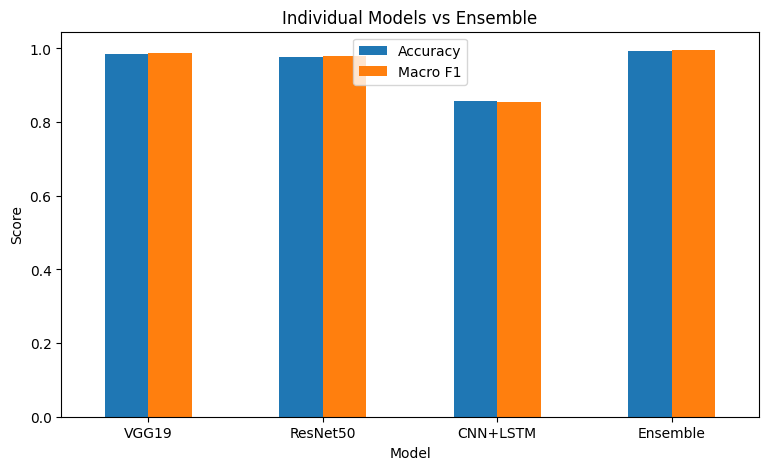

In [10]:
comparison.plot(
    x="Model",
    y=["Accuracy", "Macro F1"],
    kind="bar",
    figsize=(9,5)
)

plt.title("Individual Models vs Ensemble")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()


## Ensemble Discussion

Soft voting ensemble combines the strengths of different deep learning architectures.

The ensemble model achieved more stable predictions and improved robustness compared to individual models.
